# Regresión Lineal Múltiple

$ Y = \beta_0 + \beta_1X_1 + \beta_2X_2 + ... + + \beta_pX_p + \epsilon    $  

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import linear_model

In [9]:
# Leemos el dataset
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
dfBoston = pd.read_csv("housing.csv", header=None, delimiter=r"\s+", names=column_names, engine='python')
dfBoston.head(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


### La variable dependiente (target) es MEDV

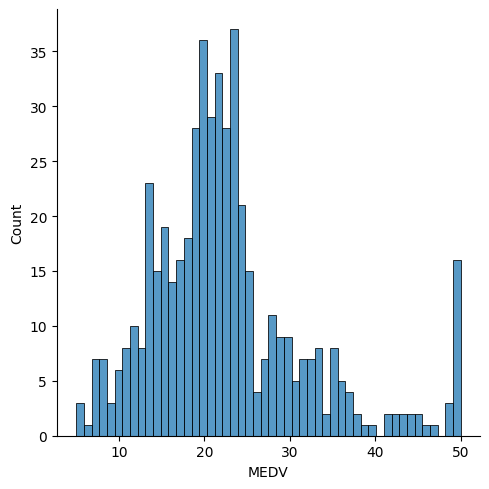

In [8]:
# Miramos la distribusión de la variable target, para ver posibles anomalías.
sns.displot(dfBoston['MEDV'], bins = 50)
plt.show()

In [10]:
# Matriz de correlación de pearson
correlacion_matriz_boston = dfBoston.corr().round(2)
plt.rcParams['figure.figsize'] = (10, 10)
correlacion_matriz_boston

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.00,-0.20,0.41,-0.06,0.42,-0.22,0.35,-0.38,0.63,0.58,0.29,-0.39,0.46,-0.39
ZN,-0.20,1.00,-0.53,-0.04,-0.52,0.31,-0.57,0.66,-0.31,-0.31,-0.39,0.18,-0.41,0.36
INDUS,0.41,-0.53,1.00,0.06,0.76,-0.39,0.64,-0.71,0.60,0.72,0.38,-0.36,0.60,-0.48
CHAS,-0.06,-0.04,0.06,1.00,0.09,0.09,0.09,-0.10,-0.01,-0.04,-0.12,0.05,-0.05,0.18
NOX,0.42,-0.52,0.76,0.09,1.00,-0.30,0.73,-0.77,0.61,0.67,0.19,-0.38,0.59,-0.43
RM,-0.22,0.31,-0.39,0.09,-0.30,1.00,-0.24,0.21,-0.21,-0.29,-0.36,0.13,-0.61,0.70
AGE,0.35,-0.57,0.64,0.09,0.73,-0.24,1.00,-0.75,0.46,0.51,0.26,-0.27,0.60,-0.38
DIS,-0.38,0.66,-0.71,-0.10,-0.77,0.21,-0.75,1.00,-0.49,-0.53,-0.23,0.29,-0.50,0.25
RAD,0.63,-0.31,0.60,-0.01,0.61,-0.21,0.46,-0.49,1.00,0.91,0.46,-0.44,0.49,-0.38
TAX,0.58,-0.31,0.72,-0.04,0.67,-0.29,0.51,-0.53,0.91,1.00,0.46,-0.44,0.54,-0.47


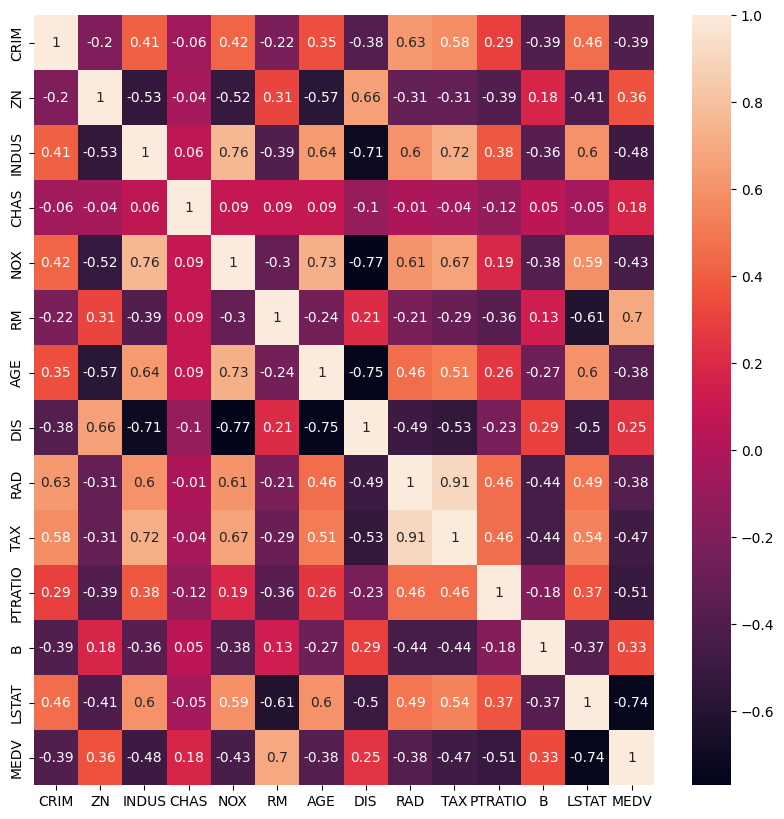

In [11]:
sns.heatmap(data = correlacion_matriz_boston, annot = True)
plt.rcParams['figure.figsize'] = (10, 10)
plt.show()

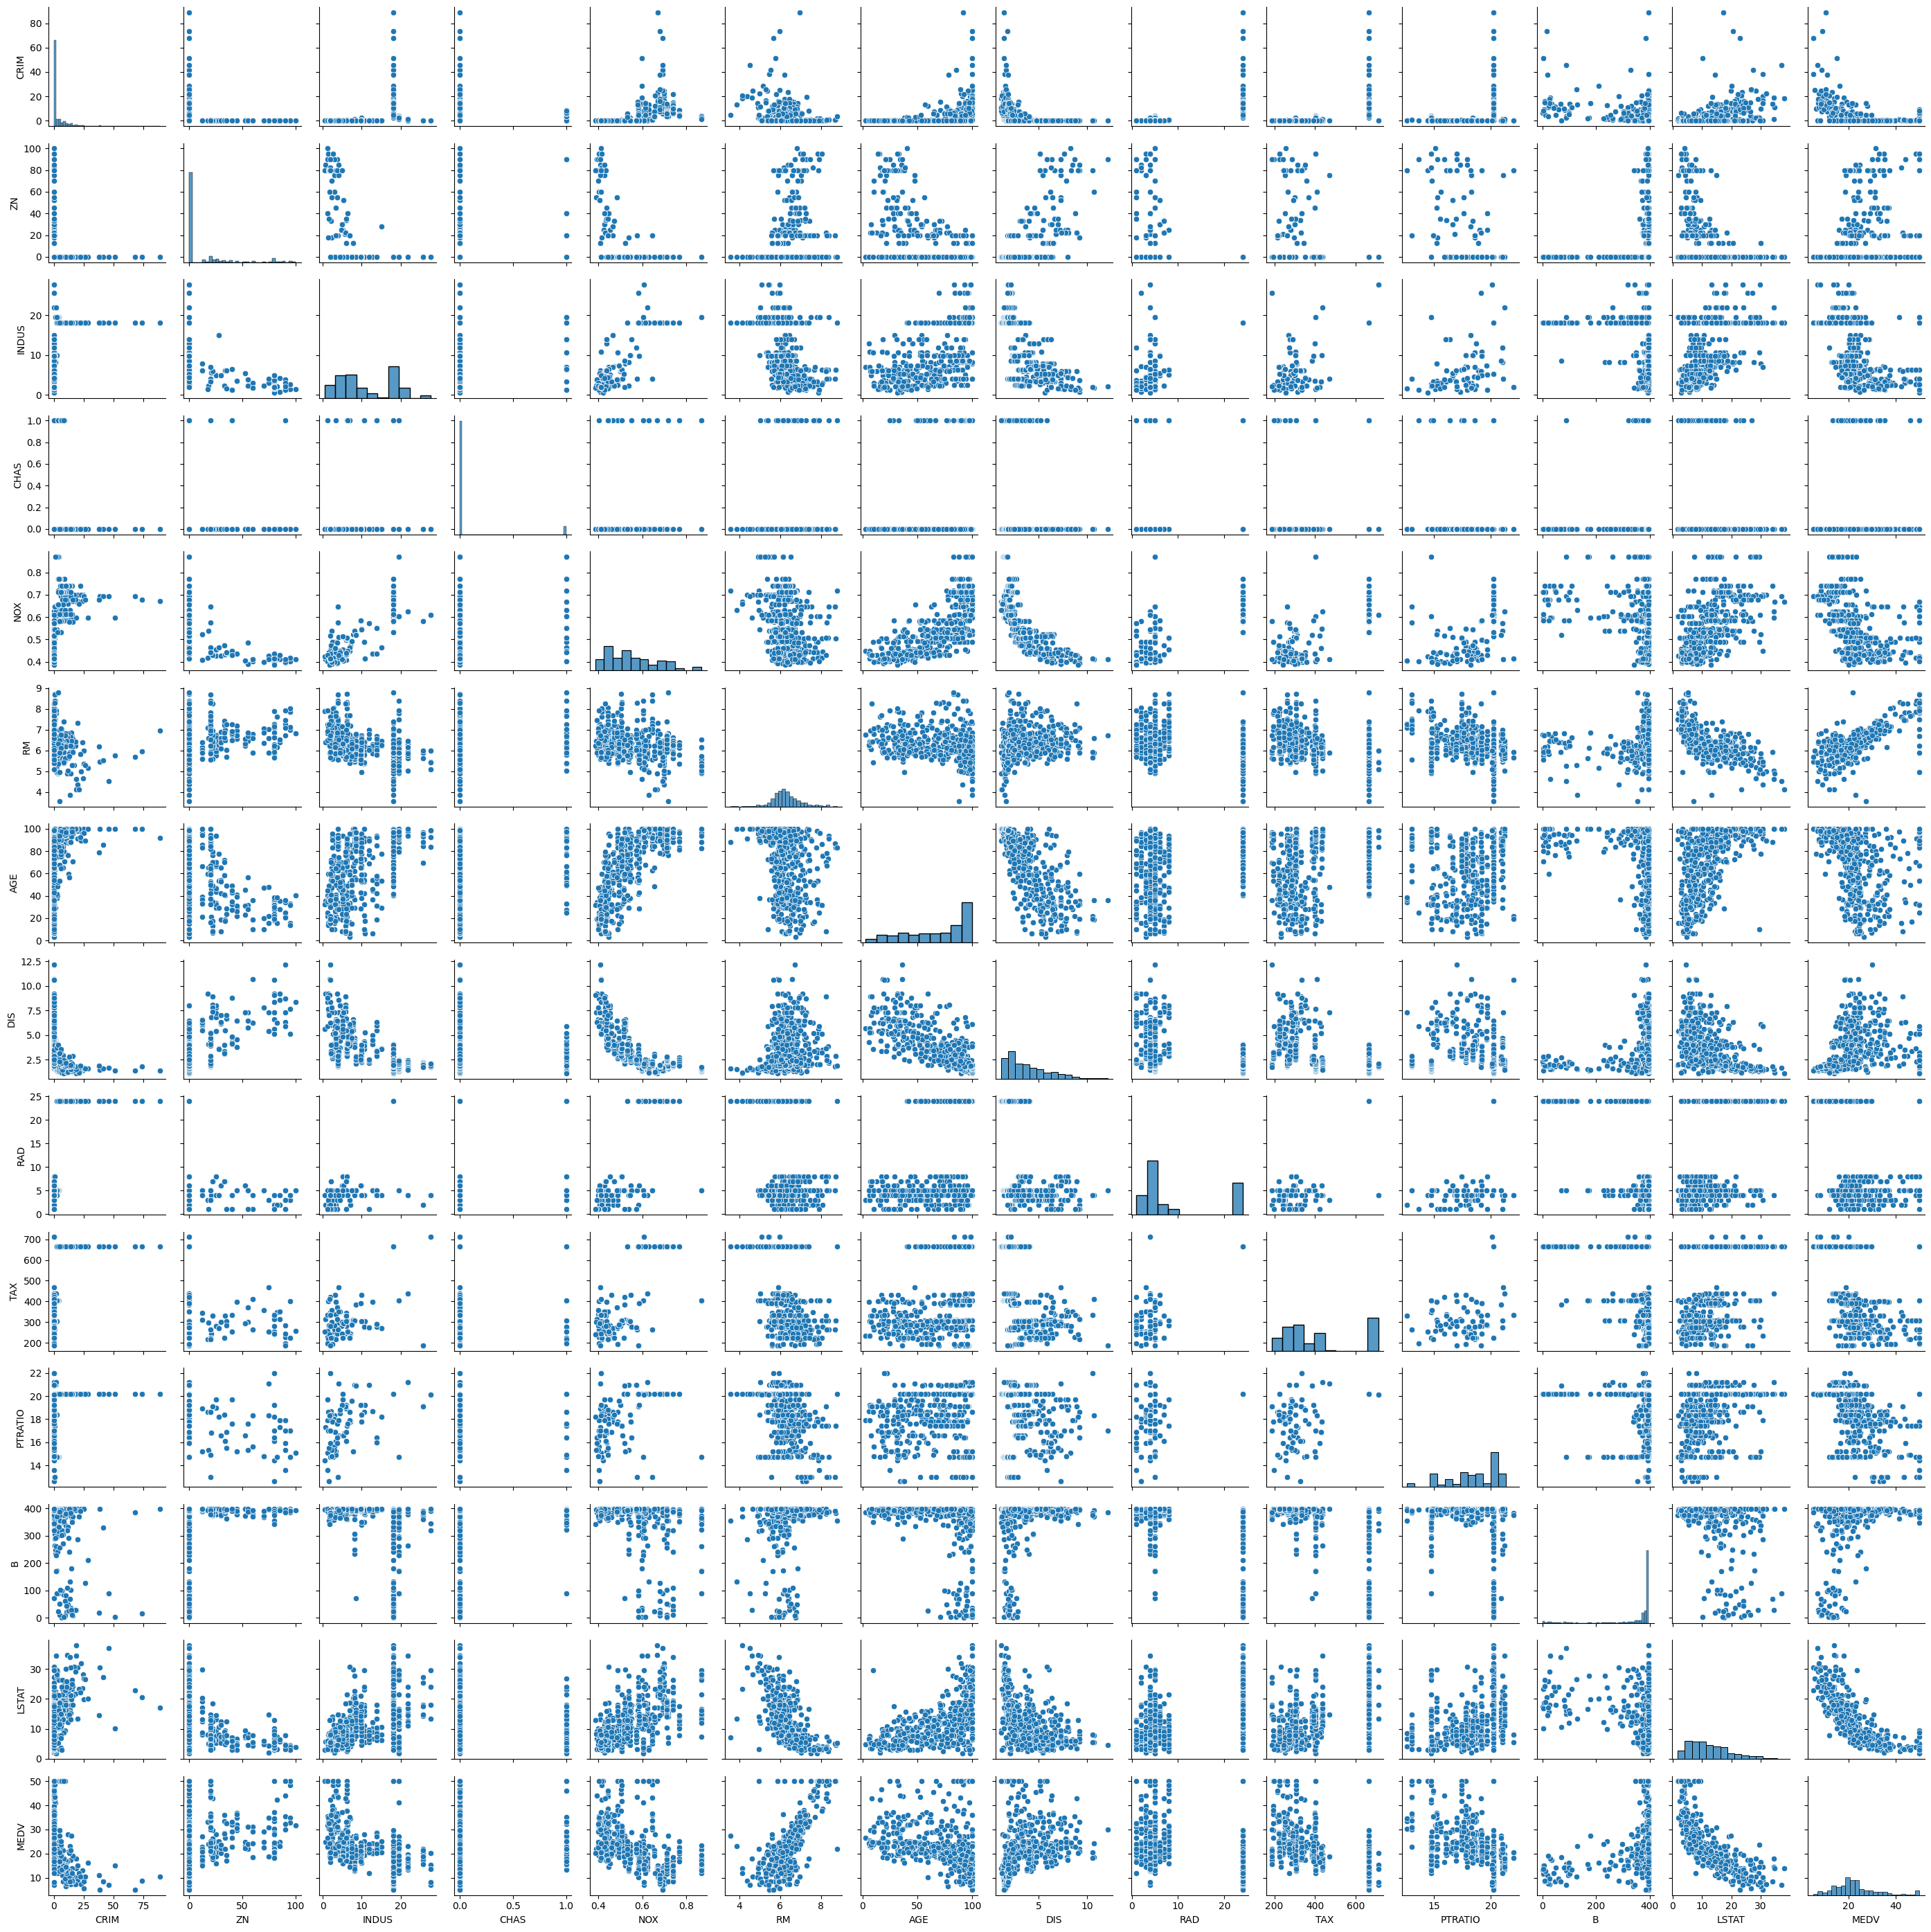

In [12]:
# Diagrama de dispersión
sns.pairplot(dfBoston, height = 2)
plt.tight_layout()

In [13]:
# Datos de entrenamiento y prueba

dfModelBoston = dfBoston[['RM', 'LSTAT', 'PTRATIO']]
dfModelBoston.head(5)

,RM,LSTAT,PTRATIO
0,6.575,4.98,15.3
1,6.421,9.14,17.8
2,7.185,4.03,17.8
3,6.998,2.94,18.7
4,7.147,5.33,18.7


In [14]:
dfModelBostonPrices = dfBoston['MEDV']
dfModelBostonPrices.head()

0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: MEDV, dtype: float64

In [16]:
# Dividimos los datos
X_train, X_test, y_train, y_test = train_test_split(dfModelBoston, dfModelBostonPrices, test_size = 0.2, random_state = 42 )

In [18]:
from sklearn.linear_model import LinearRegression
lin_mul_model_boston = LinearRegression()
lin_mul_model_boston.fit(X_train, y_train)

print('Coeficiente: m =  ', lin_mul_model_boston.coef_)
print('Término independiente: b = ', lin_mul_model_boston.intercept_)

Coeficiente: m =   [ 4.93311836 -0.56712588 -0.86709475]
Término independiente: b =  14.588099261571081


In [25]:
# Métricas del Modelo
from sklearn.metrics import r2_score
# Train
y_train_predict = lin_mul_model_boston.predict(X_train)
r2_train = r2_score(y_train, y_train_predict)         # Comparamos los datos reales con los predichos
print("El desempeño del modelo en el conjunto de train es:")
print("--------------------------------------")
print("La puntuación de R2 para TRAIN es: {}".format(r2_train))

El desempeño del modelo en el conjunto de train es:
--------------------------------------
La puntuación de R2 para TRAIN es: 0.6864566575056517


In [26]:
# Test
y_test_predict = lin_mul_model_boston.predict(X_test)
r2_test= r2_score(y_test, y_test_predict)         # Comparamos los datos reales con los predichos
print("El desempeño del modelo en el conjunto de test es:")
print("--------------------------------------")
print("La puntuación de R2 para TEST es: {}".format(r2_test))

El desempeño del modelo en el conjunto de test es:
--------------------------------------
La puntuación de R2 para TEST es: 0.6302528487272828


## R2 ajustado

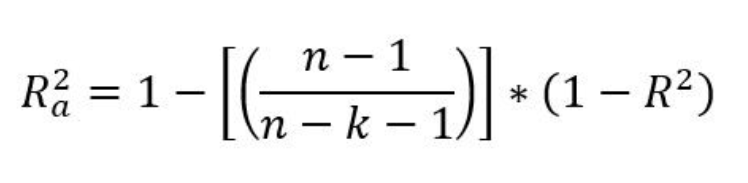

In [35]:
# R2 ajustado
n = len(y_test)   # Tamaño del conjunto test
k = dfModelBoston.shape[1]     # Número de variables predictoras

r2_ajustado = 1 - ((n-1)/(n-k-1)) * (1 - r2_test)
print("--------------------------------------")
print("La puntuación de R2 para TEST es: {}".format(r2_test))
print("La puntuación de R2 ajustado para TEST es: {}".format(r2_ajustado))

--------------------------------------
La puntuación de R2 para TEST es: 0.6302528487272828
La puntuación de R2 ajustado para TEST es: 0.6189340583821996


In [39]:
# Vamos a ver que nos predice
predicted_mult_data_boston = lin_mul_model_boston.predict(dfModelBoston)
df_boston1 = pd.DataFrame({'Real':dfBoston['MEDV'], 'Predicción': predicted_mult_data_boston})
df_boston1.head(10)

,Real,Predicción
0,24.0,30.932516
1,21.6,25.645835
2,34.7,32.312751
3,33.4,31.228040
4,36.2,30.607643
5,28.7,27.138653
6,22.9,24.016792
7,27.1,20.995005
8,16.5,12.212571
9,18.9,21.328849


In [ ]:
residuos_boston = dfBoston['RM'] - predicted_data_boston
residuos_boston

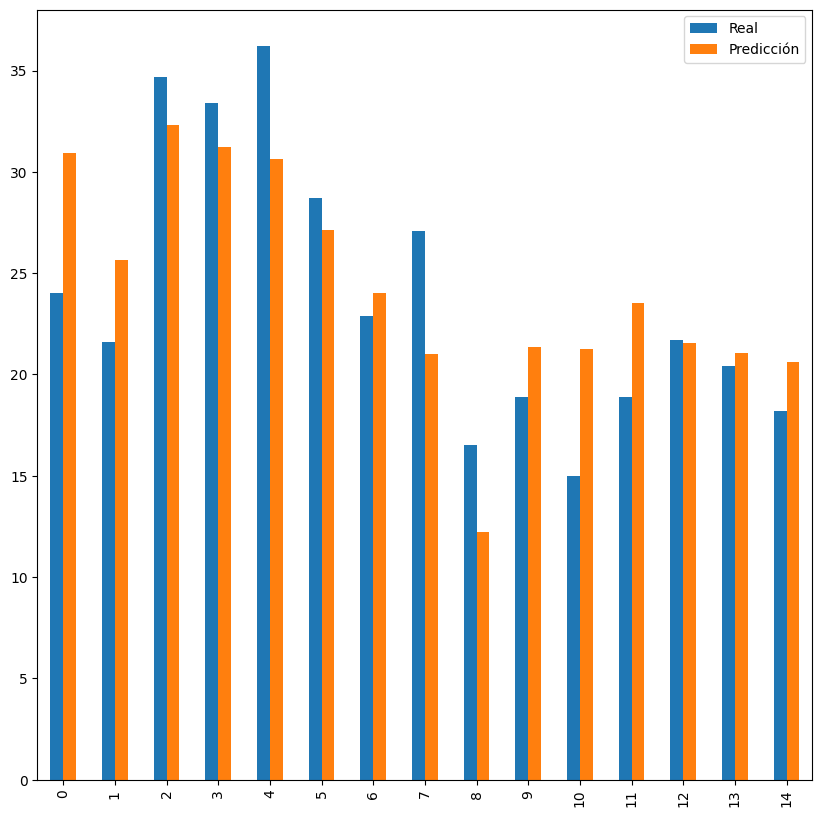

In [40]:
df_boston1.head(15).plot(kind = 'bar')
plt.show()

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split  # si quieres dividir, pero para las gráficas puedes usar todo el dataset

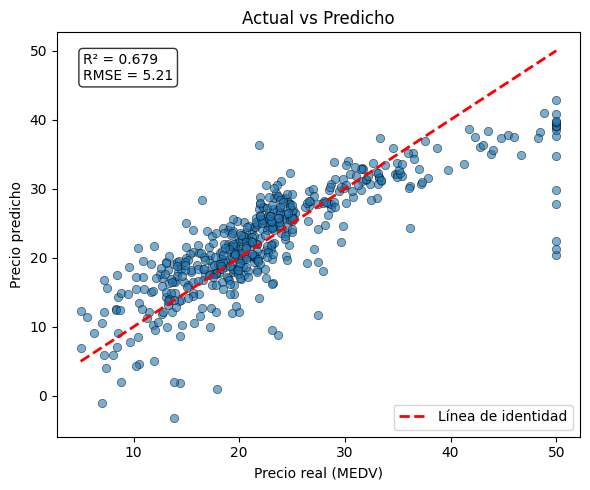

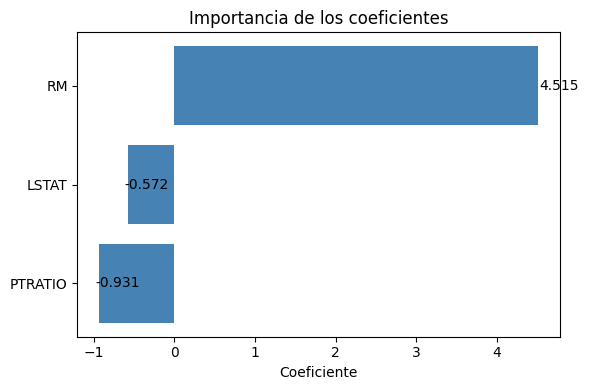

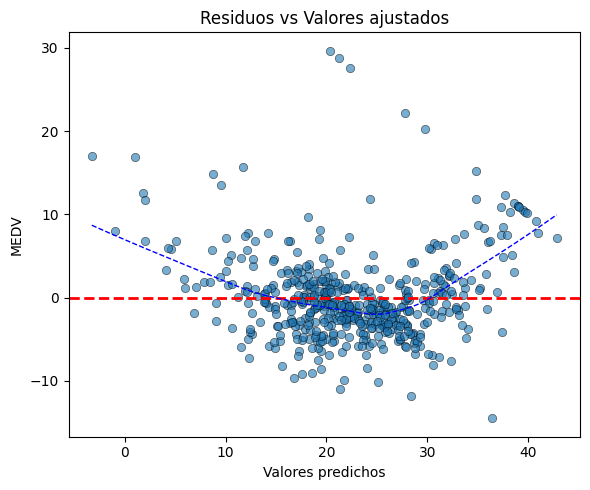

In [42]:
# Suponiendo que ya tienes dfBoston y has creado:
X = dfBoston[['RM', 'LSTAT', 'PTRATIO']]
y = dfBoston['MEDV']

# Si aún no lo has hecho, ajusta el modelo:
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# ---------- Gráfica 2: Actual vs Predicho ----------
plt.figure(figsize=(6,5))
plt.scatter(y, y_pred, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Línea de identidad')
plt.xlabel('Precio real (MEDV)')
plt.ylabel('Precio predicho')
plt.title('Actual vs Predicho')
# Añadir métricas
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
plt.text(0.05, 0.95, f'R² = {r2:.3f}\nRMSE = {rmse:.2f}', transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicho.png', dpi=150)
plt.show()

# ---------- Gráfica 3: Importancia de los coeficientes ----------
coefs = model.coef_
features = X.columns

# Ordenar para mejor visualización
indices = np.argsort(coefs)
plt.figure(figsize=(6,4))
plt.barh(range(len(features)), coefs[indices], align='center', color='steelblue')
plt.yticks(range(len(features)), features[indices])
plt.xlabel('Coeficiente')
plt.title('Importancia de los coeficientes')
# Añadir etiquetas de valor
for i, (coef, feat) in enumerate(zip(coefs[indices], features[indices])):
    plt.text(coef + (0.02 if coef>0 else -0.05), i, f'{coef:.3f}', va='center')
plt.tight_layout()
plt.savefig('coeficientes.png', dpi=150)
plt.show()

# ---------- Gráfica 4: Residuos vs Valores ajustados ----------
residuos = y - y_pred

plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuos, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Valores predichos')
plt.ylabel('Residuos')
plt.title('Residuos vs Valores ajustados')
# Añadir línea de tendencia suave opcional
sns.regplot(x=y_pred, y=residuos, lowess=True, scatter=False, color='blue', line_kws={'linestyle':'--', 'lw':1})
plt.tight_layout()
plt.savefig('residuos_vs_ajustados.png', dpi=150)
plt.show()

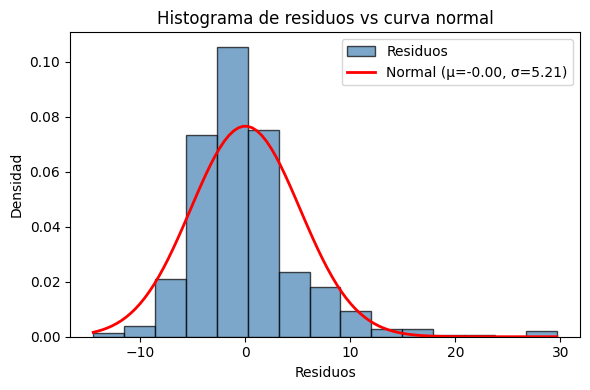

In [43]:

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Suponiendo que ya tienes y (reales) y y_pred (predichos)
residuos = y - y_pred

plt.figure(figsize=(6, 4))
n, bins, patches = plt.hist(residuos, bins=15, density=True, alpha=0.7, 
                             edgecolor='black', color='steelblue', label='Residuos')

# Ajustar una curva de distribución normal sobre el histograma
mu, std = np.mean(residuos), np.std(residuos)
x = np.linspace(residuos.min(), residuos.max(), 100)
pdf = stats.norm.pdf(x, mu, std)
plt.plot(x, pdf, 'r-', linewidth=2, label=f'Normal (μ={mu:.2f}, σ={std:.2f})')

plt.xlabel('Residuos')
plt.ylabel('Densidad')
plt.title('Histograma de residuos vs curva normal')
plt.legend()
plt.tight_layout()
plt.savefig('histograma_residuos.png', dpi=150)
plt.show()